In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # go up one level so 'blocks' is visible

import dowhy
from dowhy import CausalModel
import dowhy.datasets
import numpy as np
import pandas as pd
from blocks.draw import draw_duplo_dag, duplo_to_dot, duplo_to_networkx
from blocks.add_node import add_node
from blocks.utils import get_colors
from blocks.dowhy import dowhy_help
from blocks.simulate import simulate_data

import warnings
warnings.filterwarnings('ignore')

colors = get_colors(10)

/Users/george/Desktop/programming/projects/causal_duplo/causal_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


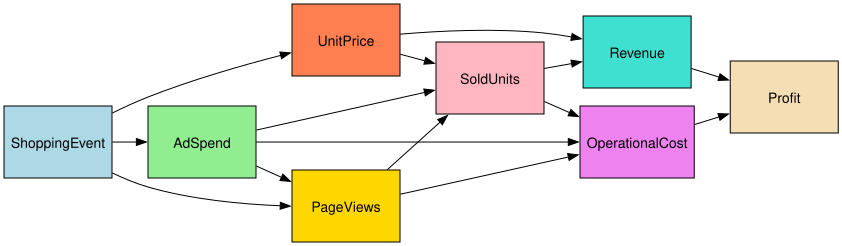

In [2]:
# Build the e-commerce DAG with meaningful names
ecommerce_dag = []
add_node(ecommerce_dag, "ShoppingEvent", colors[0], targets=["AdSpend", "UnitPrice", "PageViews"])
add_node(ecommerce_dag, "AdSpend", colors[1], targets=["PageViews", "SoldUnits", "OperationalCost"])
add_node(ecommerce_dag, "UnitPrice", colors[2], targets=["SoldUnits", "Revenue"])
add_node(ecommerce_dag, "PageViews", colors[3], targets=["SoldUnits", "OperationalCost"])
add_node(ecommerce_dag, "SoldUnits", colors[4], targets=["Revenue", "OperationalCost"])
add_node(ecommerce_dag, "Revenue", colors[5], targets=["Profit"])
add_node(ecommerce_dag, "OperationalCost", colors[6], targets=["Profit"])
add_node(ecommerce_dag, "Profit", colors[7], targets=[])

# Visualize it
draw_duplo_dag(ecommerce_dag)

# Simulate data
df_ecommerce = simulate_data(ecommerce_dag, n=1000, seed=42)

# Convert to DoWhy model
model = CausalModel(
    data=df_ecommerce,
    treatment="AdSpend",     # What you want to test
    outcome="Profit",        # What you want to optimize
    graph=duplo_to_dot(ecommerce_dag)
)

In [4]:
estimand = model.identify_effect()
print(estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                              
──────────(E[Profit|ShoppingEvent])
d[AdSpend]                         
Estimand assumption 1, Unconfoundedness: If U→{AdSpend} and U→Profit then P(Profit|AdSpend,ShoppingEvent,U) = P(Profit|AdSpend,ShoppingEvent)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
    d                              
──────────(E[Profit|ShoppingEvent])
d[AdSpend]                         
Estimand assumption 1, Unconfoundedness: If U→{AdSpend} and U→Profit then P(Profit|AdSpend,ShoppingEvent,U) = P(Profit|AdSpend,ShoppingEvent)



In [5]:
effect = model.estimate_effect(estimand, method_name="backdoor.linear_regression")
print(effect)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                              
──────────(E[Profit|ShoppingEvent])
d[AdSpend]                         
Estimand assumption 1, Unconfoundedness: If U→{AdSpend} and U→Profit then P(Profit|AdSpend,ShoppingEvent,U) = P(Profit|AdSpend,ShoppingEvent)

## Realized estimand
b: Profit~AdSpend+ShoppingEvent+AdSpend*UnitPrice
Target units: 

## Estimate
Mean value: 5.835825006211588
### Conditional Estimates
__categorical__UnitPrice
(-3.6839999999999997, -1.208]    5.744080
(-1.208, -0.329]                 5.799342
(-0.329, 0.396]                  5.835326
(0.396, 1.276]                   5.871052
(1.276, 4.575]                   5.929325
dtype: float64


In [6]:
from blocks.regression import regression

In [7]:
naive_model = regression(df_ecommerce, "AdSpend", "Profit")
naive_coef = naive_model.params["AdSpend"]
print(f"Naive regression coefficient: {naive_coef:.4f}")

Naive regression coefficient: 8.8420


In [8]:
refutation = model.refute_estimate(estimand, effect, method_name="random_common_cause")
print(f"Original: {effect.value:.4f}")
print(f"With random confounder: {refutation.new_effect:.4f}")

Original: 5.8358
With random confounder: 5.8360


In [9]:
dowhy_help('tests')

=== DoWhy Refutation Tests ===

🔍 ROBUSTNESS TESTS:
• random_common_cause
  - Adds random confounder to test sensitivity - change should be close to 0

• placebo_treatment_refuter
  - Replaces treatment with random variable - placebo effect should be close to 0

• data_subset_refuter
  - Tests on random subsets of data - change should be close to 0

• add_unobserved_common_cause
  - Simulates unobserved confounding - change should be close to 0

🎯 USAGE:
refutation = model.refute_estimate(estimand, effect, method_name='test_name')


In [10]:
refutation = model.refute_estimate(estimand, effect, method_name="placebo_treatment_refuter")
print(f"Original: {effect.value:.4f}")
print(f"With random confounder: {refutation.new_effect:.4f}")

Original: 5.8358
With random confounder: 0.0000


In [11]:
refutation = model.refute_estimate(estimand, effect, method_name="data_subset_refuter")
print(f"Original: {effect.value:.4f}")
print(f"With random confounder: {refutation.new_effect:.4f}")

Original: 5.8358
With random confounder: 5.8409


# Continuing with the Tutorial to Learn Advanced Features Related to GCM

### This networkx graph is used for analysis and gcm, (but can also be visualised)

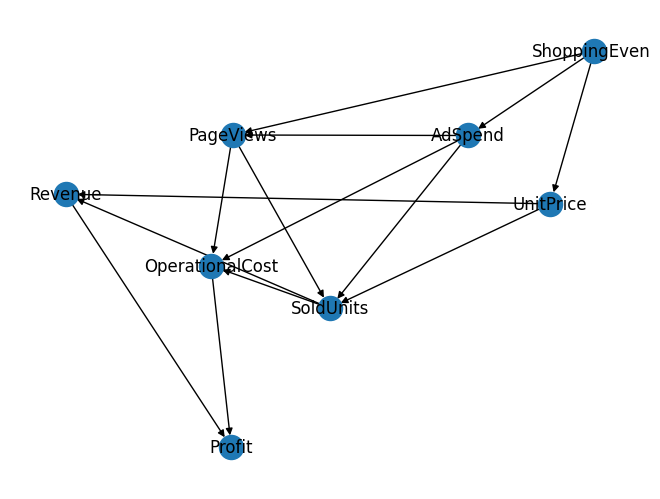

In [15]:
import matplotlib.pyplot as plt
import networkx as nx

nx_graph = duplo_to_networkx(ecommerce_dag)
nx.draw(nx_graph, with_labels=True)
plt.show()